# Consistency analysis — ReScience-C corpus

Reproducibility index over per-`(paper, model, temperature, sample)` profiles in `data/experiments/consistency_checks/rescience_c/`. Scoring construction: `reproducibility_score.md`. All scoring lives in `repro_scoring.py`; this notebook is narrative + plot only.

**Figure 1**: model comparison — per-model `repro_index` distribution across 10 papers (box + strip, pooled over T × samples).  
**Figure 2**: run-to-run variability — std of `repro_index` vs. temperature, one line per paper, small-multiples layout.  
**Figure 8**: cross-notebook validation — single-run T = 0 scores vs. 10-sample consistency band for `gemini-3.1-pro-preview`.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Patch

from repro_scoring import load_runs

PROFILE_DIR = Path("data/experiments/consistency_checks/rescience_c")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

PAPER_META = {
    "2017_04_article.pdf": (4, 3372),
    "2020_26_article.pdf": (8, 3701),
    "2017_01_article.pdf": (15, 6436),
    "2025_03_article.pdf": (20, 8930),
    "2017_08_article.pdf": (11, 9237),
    "2022_30_article.pdf": (18, 9800),
    "2021_34_article.pdf": (28, 13493),
    "2023_17_article.pdf": (24, 14733),
    "2023_15_article.pdf": (30, 16170),
    "2022_38_article.pdf": (34, 22917),
}
meta = (
    pd.DataFrame.from_dict(PAPER_META, orient="index", columns=["n_pages", "n_words"])
    .rename_axis("paper")
    .reset_index()
)

## Load and score every profile

`load_runs` walks the profile directory, parses `(paper, T, sample, model)` from each filename, builds the workflow graph, and computes `structural`, `content`, and `repro_index = sqrt(structural · content)`.

In [2]:
long = pd.DataFrame(load_runs(PROFILE_DIR)).merge(meta, on="paper", how="left")
print(f"runs: {len(long):,}; models: {sorted(long['model'].unique())}")
long.head()

runs: 1,804; models: ['gemini-2.5-flash', 'gemini-2.5-pro', 'gemini-3-flash-preview', 'gemini-3.1-pro-preview']


,paper,temperature,sample,model,structural,content,repro_index,n_source,n_process,n_sink,n_pages,n_words
0,2017_01_article.pdf,0.0,10,gemini-2.5-flash,0.66655,0.868571,0.760885,1.0,7.0,23.0,15,6436
1,2017_01_article.pdf,0.0,10,gemini-2.5-pro,0.60000,0.442857,0.515475,0.0,4.0,2.0,15,6436
2,2017_01_article.pdf,0.0,10,gemini-3-flash-preview,0.60000,0.788571,0.687854,0.0,5.0,2.0,15,6436
3,2017_01_article.pdf,0.0,10,gemini-3.1-pro-preview,0.60000,0.861905,0.719126,0.0,3.0,2.0,15,6436
4,2017_01_article.pdf,0.0,1,gemini-2.5-flash,0.66655,0.868571,0.760885,1.0,7.0,23.0,15,6436


## Aggregate per `(model, paper)`

Mean and standard deviation of `repro_index` pooled over all temperature × sample runs for each `(model, paper)` pair. Single-run cells (where `std` is undefined) are filled with `0.0` so they still plot.

In [3]:
agg = (
    long.groupby(["model", "paper", "n_pages", "n_words"], as_index=False)["repro_index"]
    .agg(mean="mean", std="std", n="count")
    .sort_values(["model", "n_words"])
    .assign(std=lambda df: df["std"].fillna(0.0))
)
agg

,model,paper,n_pages,n_words,mean,std,n
1,gemini-2.5-flash,2017_04_article.pdf,4,3372,0.677738,0.108171,47
3,gemini-2.5-flash,2020_26_article.pdf,8,3701,0.762451,0.091436,38
0,gemini-2.5-flash,2017_01_article.pdf,15,6436,0.815550,0.117367,42
9,gemini-2.5-flash,2025_03_article.pdf,20,8930,0.673443,0.064221,35
2,gemini-2.5-flash,2017_08_article.pdf,11,9237,0.676026,0.056019,40
5,gemini-2.5-flash,2022_30_article.pdf,18,9800,0.692437,0.080660,22
4,gemini-2.5-flash,2021_34_article.pdf,28,13493,0.714486,0.122383,31
8,gemini-2.5-flash,2023_17_article.pdf,24,14733,0.915123,0.028920,37
7,gemini-2.5-flash,2023_15_article.pdf,30,16170,0.771845,0.048027,44
6,gemini-2.5-flash,2022_38_article.pdf,34,22917,0.761496,0.068445,30


## Figure 1 — Model comparison

Box plot with strip overlay: one box per model showing the distribution of paper-level mean `repro_index` values (pooled across all temperature × sample runs). Individual paper means are overlaid as jittered dots coloured by paper identity (tab10 palette). The consistent separation between model boxes supports the claim that model ranking is stable across papers.

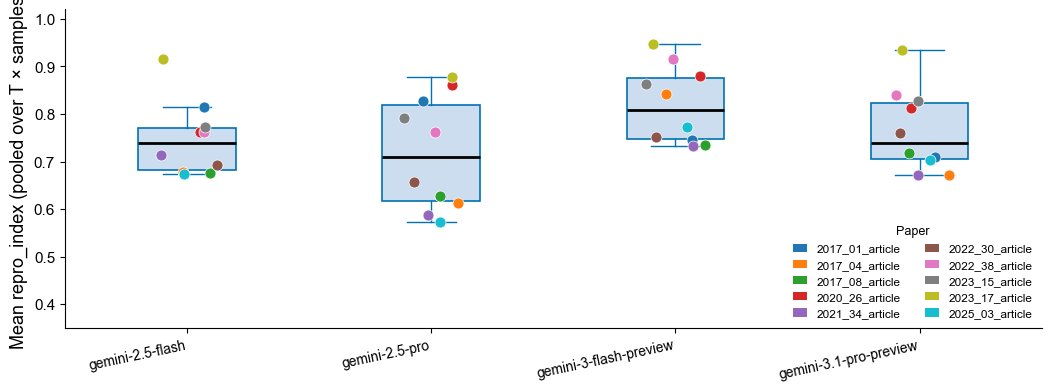

In [4]:
OKABE_ITO = [
    "#0072B2", "#D55E00", "#009E73", "#CC79A7",
    "#E69F00", "#56B4E9", "#F0E442", "#000000",
]

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
    }
)

# model→Okabe-Ito colour mapping (reused by downstream cells)
models = sorted(agg["model"].unique())
colors = {m: OKABE_ITO[i % len(OKABE_ITO)] for i, m in enumerate(models)}

# ── Figure 1 — model comparison (box + strip) ────────────────────────────────
paper_list  = sorted(agg["paper"].unique())
cmap10      = plt.get_cmap("tab10")
paper_color = {p: cmap10(i / max(len(paper_list) - 1, 1)) for i, p in enumerate(paper_list)}

data_by_model = [agg[agg["model"] == m]["mean"].values for m in models]

# fig, ax = plt.subplots(figsize=(9.0, 5.2), constrained_layout=True)
fig, ax = plt.subplots(
    figsize=(2.6 * len(models), 3.8),
    constrained_layout=True
)

ax.boxplot(
    data_by_model,
    positions=range(len(models)),
    widths=0.40,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 2.0},
    boxprops={"facecolor": "#CCDDEF", "edgecolor": "#0072B2", "linewidth": 1.2},
    whiskerprops={"color": "#0072B2", "linewidth": 1.0},
    capprops={"color": "#0072B2", "linewidth": 1.0},
)

rng = np.random.default_rng(42)
for xi, m in enumerate(models):
    sub    = agg[agg["model"] == m].sort_values("paper")
    jitter = rng.uniform(-0.13, 0.13, size=len(sub))
    for (_, row), jit in zip(sub.iterrows(), jitter):
        ax.scatter(
            xi + jit, row["mean"],
            color=paper_color[row["paper"]], s=62, zorder=4,
            edgecolors="white", linewidths=0.5,
        )

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, fontsize=10, rotation=12, ha="right")
ax.set_ylabel("Mean repro_index (pooled over T \u00d7 samples)")
ax.set_ylim(0.35, 1.02)
ax.margins(x=0.10)

legend_handles = [
    Patch(facecolor=paper_color[p], edgecolor="none", label=p.removesuffix(".pdf"))
    for p in paper_list
]
ax.legend(
    handles=legend_handles, title="Paper", title_fontsize=9,
    loc="lower right", fontsize=8.5, ncol=2,
    borderaxespad=0.4, handlelength=1.2,
)

fig.savefig(FIGURE_DIR / "fig1_model_comparison.pdf")
fig.savefig(FIGURE_DIR / "fig1_model_comparison.png")
plt.show()

### Supplementary Figure S1 — Repro_index vs paper length

Per-model `repro_index` vs. paper length (words) with shaded `mean ± std` band (pooled over all T × samples). No consistent monotonic trend is observed; paper identity dominates over length as a predictor of reproducibility (see Figure 1).

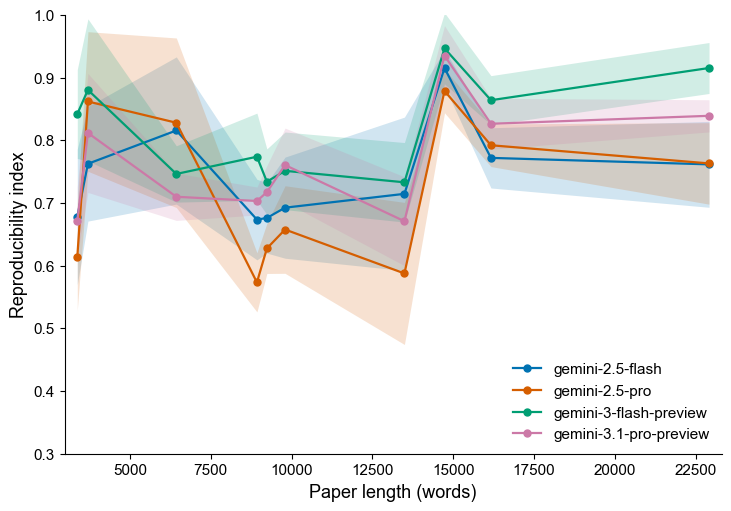

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 5.0), constrained_layout=True)

for m in models:
    sub = agg[agg["model"] == m].sort_values("n_words")
    x = sub["n_words"].to_numpy()
    y = sub["mean"].to_numpy()
    e = sub["std"].to_numpy()
    ax.fill_between(x, y - e, y + e, color=colors[m], alpha=0.18, linewidth=0)
    ax.plot(
        x, y,
        marker="o", markersize=5.0, linewidth=1.6,
        color=colors[m], label=m, clip_on=False,
    )

ax.set_xlabel("Paper length (words)")
ax.set_ylabel("Reproducibility index")
ax.set_ylim(0.3, 1)
ax.margins(x=0.02)
ax.legend(loc="lower right", borderaxespad=0.4, handlelength=1.8)

fig.savefig(FIGURE_DIR / "figS1_repro_vs_paper_length.pdf")
fig.savefig(FIGURE_DIR / "figS1_repro_vs_paper_length.png")
plt.show()

## Per-temperature plots: $T=0$ vs. $T=2$

Same construction as the pooled plot above, but the long table is filtered to one temperature before aggregating per `(model, paper)`. $T=0$ is the deterministic regime (residual variance comes from non-determinism in the API); $T=2$ is the high-stochasticity end of the Gemini / GPT temperature ranges. Comparing the two isolates how much of the run-to-run spread is driven by sampling temperature versus by paper / model effects.

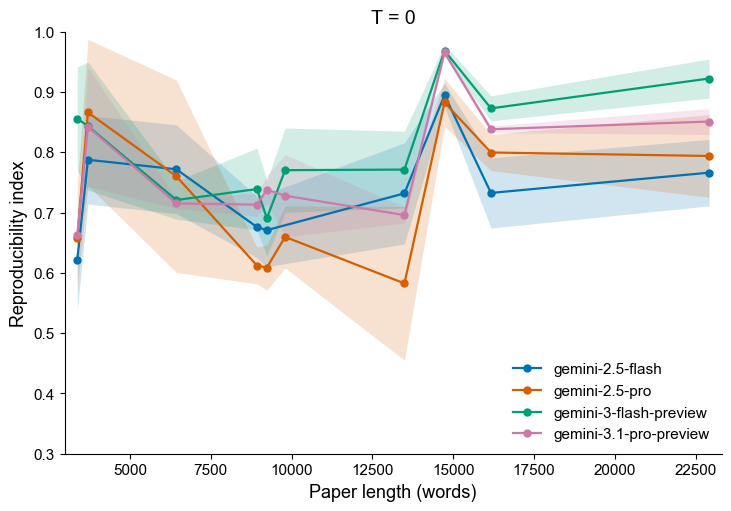

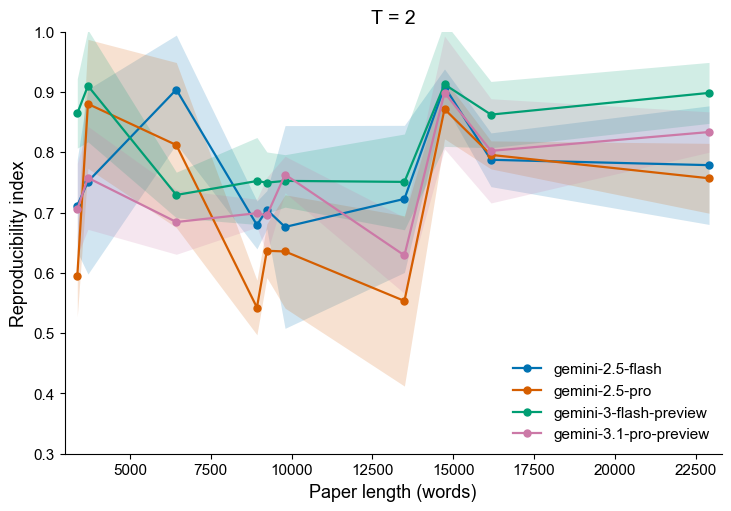

In [6]:
def plot_repro_vs_length(df: pd.DataFrame, title: str, savestem: str) -> None:
    sub_agg = (
        df.groupby(["model", "paper", "n_pages", "n_words"], as_index=False)["repro_index"]
        .agg(mean="mean", std="std", n="count")
        .sort_values(["model", "n_words"])
        .assign(std=lambda d: d["std"].fillna(0.0))
    )
    fig, ax = plt.subplots(figsize=(7.2, 5.0), constrained_layout=True)
    for m in sorted(sub_agg["model"].unique()):
        s = sub_agg[sub_agg["model"] == m].sort_values("n_words")
        x, y, e = s["n_words"].to_numpy(), s["mean"].to_numpy(), s["std"].to_numpy()
        ax.fill_between(x, y - e, y + e, color=colors[m], alpha=0.18, linewidth=0)
        ax.plot(
            x, y,
            marker="o", markersize=5.0, linewidth=1.6,
            color=colors[m], label=m, clip_on=False,
        )
    ax.set_xlabel("Paper length (words)")
    ax.set_ylabel("Reproducibility index")
    ax.set_title(title)
    ax.set_ylim(0.3, 1.0)
    ax.margins(x=0.02)
    ax.legend(loc="lower right", borderaxespad=0.4, handlelength=1.8)
    fig.savefig(FIGURE_DIR / f"{savestem}.pdf")
    fig.savefig(FIGURE_DIR / f"{savestem}.png")
    plt.show()


plot_repro_vs_length(
    long[long["temperature"] == 0.0],
    title="T = 0",
    savestem="repro_vs_paper_length_T0",
)
plot_repro_vs_length(
    long[long["temperature"] == 2.0],
    title="T = 2",
    savestem="repro_vs_paper_length_T2",
)

## Figure 2 — Run-to-run variability across temperature (small multiples)

One panel per model, shared $x$ and $y$ axes. Inside each panel, every line is one paper; the line traces the **standard deviation of `repro_index`** across the 10 samples at each `(model, paper, temperature)` cell, evaluated at $T \in \{0, 0.5, 1, 1.5, 2\}$. Line colour encodes paper length (words) on a perceptually-uniform scale.

Three patterns visible at a glance: (i) whether longer papers are harder to reproduce consistently (separation between dark and light lines); (ii) whether sampling temperature inflates run-to-run spread (slope of each line); (iii) which model is most internally consistent across temperatures (overall vertical level).

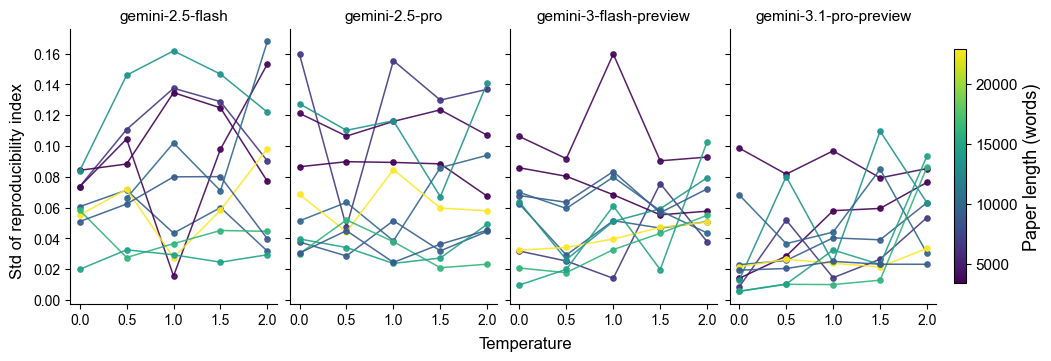

In [7]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

var_table = (
    long.groupby(["model", "paper", "n_words", "temperature"], as_index=False)["repro_index"]
    .std()
    .rename(columns={"repro_index": "std_repro"})
    .dropna(subset=["std_repro"])
)

models_panel = sorted(var_table["model"].unique())
norm = Normalize(vmin=var_table["n_words"].min(), vmax=var_table["n_words"].max())
cmap = plt.get_cmap("viridis")

# fig, axes = plt.subplots(2, 3, figsize=(12.0, 6.8), sharex=True, sharey=True, constrained_layout=True)
fig, axes = plt.subplots(1, len(models_panel), figsize=(2.6 * len(models_panel), 3.5),
                         sharex=True, sharey=True, constrained_layout=True)
axes_flat = axes.flatten()

for idx, m in enumerate(models_panel):
    ax = axes_flat[idx]
    for _, grp in var_table[var_table["model"] == m].groupby("paper"):
        grp = grp.sort_values("temperature")
        ax.plot(
            grp["temperature"], grp["std_repro"],
            marker="o", markersize=3.8, linewidth=1.1,
            color=cmap(norm(grp["n_words"].iloc[0])),
            alpha=0.9,
        )
    ax.set_title(m, fontsize=11)
    ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

for j in range(len(models_panel), len(axes_flat)):
    axes_flat[j].set_axis_off()

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(
    sm,
    ax=axes_flat[: len(models_panel)],
    location="right",
    shrink=0.85,
    pad=0.02,
    label="Paper length (words)",
)

fig.supxlabel("Temperature", fontsize=12)
fig.supylabel("Std of reproducibility index", fontsize=12)

fig.savefig(FIGURE_DIR / "fig2_temperature_sensitivity.pdf")
fig.savefig(FIGURE_DIR / "fig2_temperature_sensitivity.png")
plt.show()

## Failure counts by model × temperature

Heatmap of `(model, temperature)` cells with failure counts pulled from `run_timings.csv`. A row is a failure when its `status` column is anything other than `ok` — typically `err:<ExceptionType>` written by the sweep when the analyst raised. Cells that were never attempted (missing from the CSV) are not the same as failures and show as `0` here; mind that distinction when interpreting low counts.

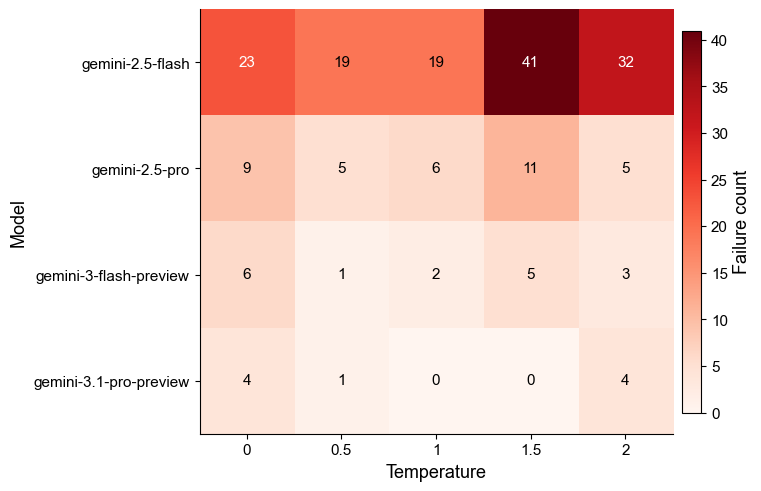

totals by model:
model
gemini-2.5-flash          134
gemini-2.5-pro             36
gemini-3-flash-preview     17
gemini-3.1-pro-preview      9


In [8]:
timings = pd.read_csv(PROFILE_DIR / "run_timings.csv")

fail_pivot = (
    timings[timings["status"] != "ok"]
    .groupby(["model", "temperature"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=sorted(timings["model"].unique()), fill_value=0)
    .reindex(columns=sorted(timings["temperature"].unique()), fill_value=0)
)

fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)

vmax = max(int(fail_pivot.values.max()), 1)
im = ax.imshow(fail_pivot.values, cmap="Reds", aspect="auto", vmin=0, vmax=vmax)

ax.set_xticks(range(len(fail_pivot.columns)))
ax.set_xticklabels([f"{t:g}" for t in fail_pivot.columns])
ax.set_yticks(range(len(fail_pivot.index)))
ax.set_yticklabels(fail_pivot.index)
ax.set_xlabel("Temperature")
ax.set_ylabel("Model")

threshold = vmax / 2
for i in range(fail_pivot.shape[0]):
    for j in range(fail_pivot.shape[1]):
        v = int(fail_pivot.iat[i, j])
        ax.text(
            j, i, str(v),
            ha="center", va="center",
            color="white" if v > threshold else "black",
            fontsize=11,
        )

fig.colorbar(im, ax=ax, label="Failure count", shrink=0.9, pad=0.02)

fig.savefig(FIGURE_DIR / "failures_by_model_temp.pdf")
fig.savefig(FIGURE_DIR / "failures_by_model_temp.png")
plt.show()

print("totals by model:")
print(fail_pivot.sum(axis=1).to_string())

## Node-count breakdown by layer

`score_profile` now returns three additional columns — `n_source`, `n_process`, `n_sink` — counting the entries in each layer of the extracted profile. These are not derived from the graph, just the raw lengths of `nodes_source` / `nodes_process` / `nodes_sink`. The two plots below show the per-layer mean count, first as a function of sampling temperature and then as a function of paper length.

The reading is interpretive, not normative — there is no "correct" number of source or sink nodes for a paper. Inflation can mean the analyst is over-decomposing; deflation can mean it is missing structure. Comparing across models at fixed paper / temperature isolates model-specific decomposition styles; comparing across paper length isolates whether the analyst scales with the paper's actual content.

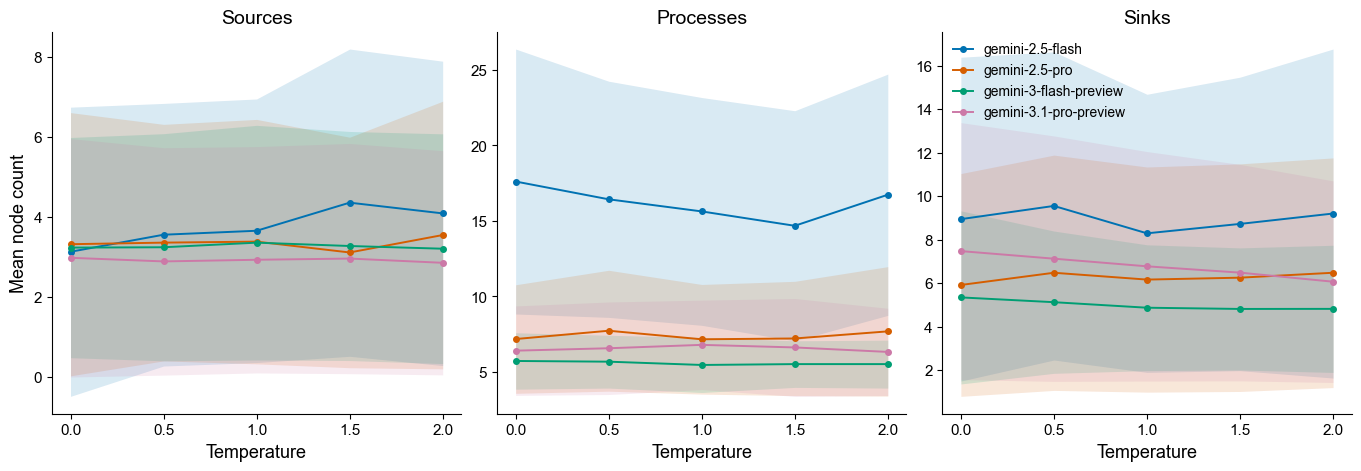

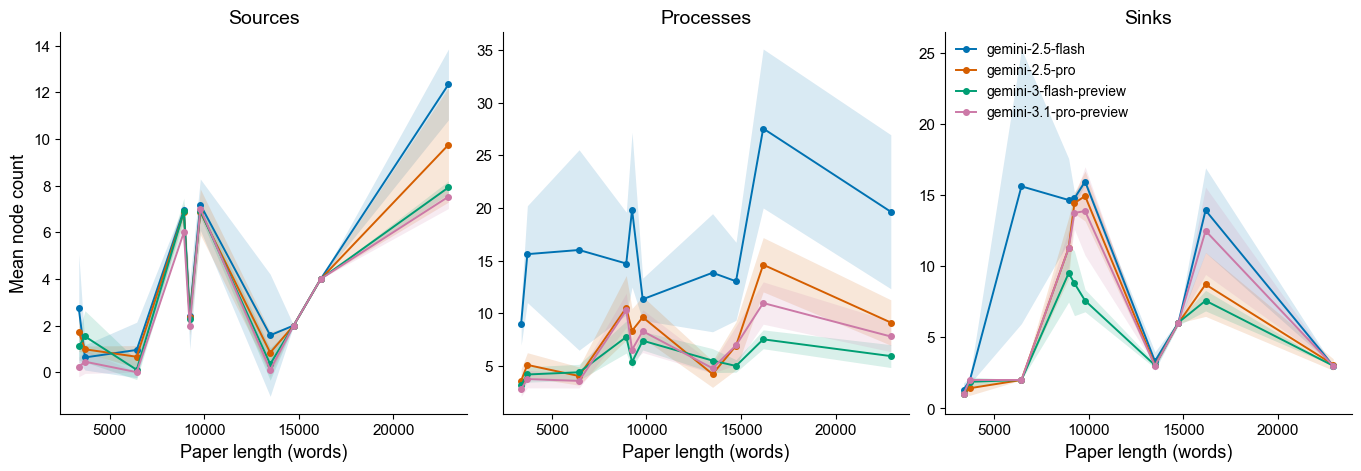

In [9]:
LAYER_LABEL = {"n_source": "Sources", "n_process": "Processes", "n_sink": "Sinks"}

missing = [c for c in LAYER_LABEL if c not in long.columns]
if missing:
    raise RuntimeError(
        f"`long` is missing {missing}. Re-run the load cell (rl-11) so that "
        "the updated `repro_scoring.score_profile` (now returning node counts) "
        "flows into the dataframe."
    )


def _plot_node_counts(by: str, x_label: str, x_ticks=None, savestem: str = "") -> None:
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharex=True, constrained_layout=True)
    for ax, (col, title) in zip(axes, LAYER_LABEL.items(), strict=True):
        agg_layer = (
            long.groupby(["model", by])[col]
            .agg(["mean", "std"])
            .reset_index()
        )
        agg_layer["std"] = agg_layer["std"].fillna(0.0)
        for m in sorted(long["model"].unique()):
            sub = agg_layer[agg_layer["model"] == m].sort_values(by)
            x = sub[by].to_numpy()
            y = sub["mean"].to_numpy()
            e = sub["std"].to_numpy()
            ax.fill_between(x, y - e, y + e, color=colors[m], alpha=0.15, linewidth=0)
            ax.plot(
                x, y,
                marker="o", markersize=4.0, linewidth=1.4,
                color=colors[m], label=m,
            )
        ax.set_title(title)
        ax.set_xlabel(x_label)
        if x_ticks is not None:
            ax.set_xticks(x_ticks)

    axes[0].set_ylabel("Mean node count")
    axes[-1].legend(loc="upper left", borderaxespad=0.4, handlelength=1.4, fontsize=10)

    fig.savefig(FIGURE_DIR / f"{savestem}.pdf")
    fig.savefig(FIGURE_DIR / f"{savestem}.png")
    plt.show()


_plot_node_counts(
    by="temperature",
    x_label="Temperature",
    x_ticks=[0.0, 0.5, 1.0, 1.5, 2.0],
    savestem="nodes_by_model_temp",
)
_plot_node_counts(
    by="n_words",
    x_label="Paper length (words)",
    savestem="nodes_by_model_paper_length",
)

### Node counts by paper length × temperature (box plot)

Three panels (Sources / Processes / Sinks). Within each panel, the x-axis lists the 10 papers ordered by length; at every paper there are five boxes, one per sampled temperature, coloured on a `viridis` gradient. Each box is the distribution of node counts across all 5 models × 10 samples for that `(paper, T)` cell — typically ~50 points. Models are pooled, so the box height absorbs model-to-model decomposition disagreement on top of sample-to-sample noise.

Fliers are omitted: with 150 boxes the dot density would obscure the medians. Whiskers still extend to $1.5 \times \text{IQR}$, so any genuinely large outliers will still be visible at the whisker tips.

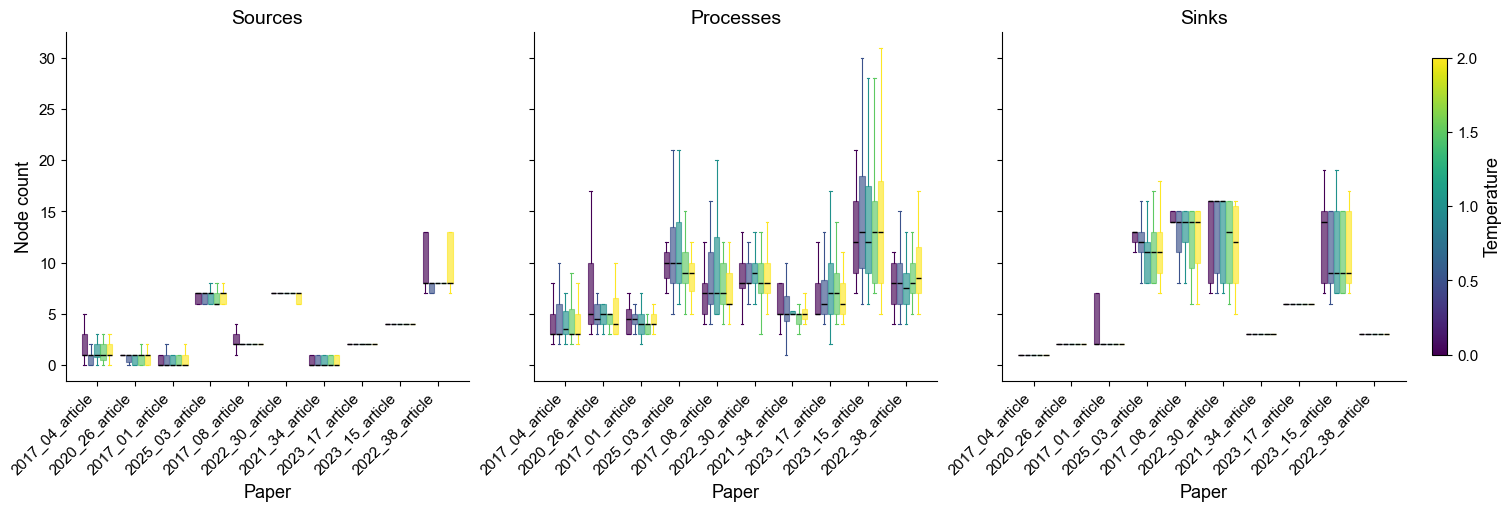

In [10]:
temps_present = sorted(long["temperature"].unique())
norm_t = Normalize(vmin=min(temps_present), vmax=max(temps_present))
cmap_t = plt.get_cmap("viridis")
temp_colors = {t: cmap_t(norm_t(t)) for t in temps_present}

papers_sorted = long.groupby("paper")["n_words"].first().sort_values().index.tolist()
paper_label = {p: p.removesuffix(".pdf") for p in papers_sorted}

group_width = 0.82
box_width = group_width / len(temps_present)
x_base = np.arange(len(papers_sorted))

fig, axes = plt.subplots(1, 3, figsize=(15.0, 5.0), sharex=True, sharey=True, constrained_layout=True)
for ax, (col, title) in zip(axes, LAYER_LABEL.items(), strict=True):
    for i, t in enumerate(temps_present):
        offset = (i - (len(temps_present) - 1) / 2) * box_width
        data = [
            long[(long.temperature == t) & (long.paper == p)][col].to_numpy()
            for p in papers_sorted
        ]
        ax.boxplot(
            data,
            positions=x_base + offset,
            widths=box_width * 0.85,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.0},
            whiskerprops={"color": temp_colors[t], "linewidth": 0.8},
            capprops={"color": temp_colors[t], "linewidth": 0.8},
            boxprops={
                "facecolor": temp_colors[t], "edgecolor": temp_colors[t],
                "alpha": 0.65, "linewidth": 0.8,
            },
        )
    ax.set_xticks(x_base)
    ax.set_xticklabels(
        [paper_label[p] for p in papers_sorted],
        rotation=45, ha="right",
    )
    ax.set_xlabel("Paper")
    ax.set_title(title)
    ax.margins(x=0.02)

axes[0].set_ylabel("Node count")

sm = ScalarMappable(norm=norm_t, cmap=cmap_t)
sm.set_array([])
fig.colorbar(
    sm, ax=axes, location="right",
    shrink=0.85, pad=0.02,
    label="Temperature", ticks=temps_present,
)

fig.savefig(FIGURE_DIR / "nodes_box_by_temp_paper_length.pdf")
fig.savefig(FIGURE_DIR / "nodes_box_by_temp_paper_length.png")
plt.show()

### Node counts by paper length × model (box plot)

Same three-panel layout, but boxes are now coloured by **model** instead of temperature. At every paper-tick there are 5 boxes — one per model — and each box pools over all 5 temperatures × 10 samples for that `(model, paper)` cell (~50 points). This view isolates model-specific decomposition style: differences in box height *within* a paper-tick reflect how each model partitions the same source / process / sink structure differently.

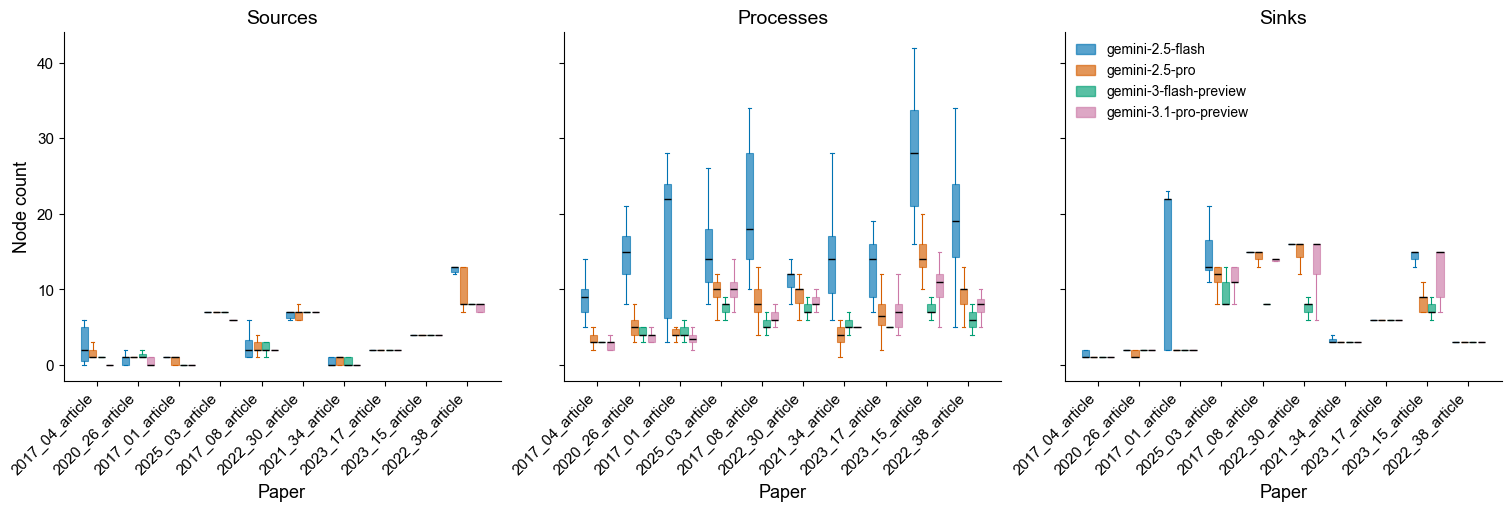

In [11]:
papers_sorted = long.groupby("paper")["n_words"].first().sort_values().index.tolist()
paper_label = {p: p.removesuffix(".pdf") for p in papers_sorted}
models_box = sorted(long["model"].unique())

group_width = 0.82
box_width = group_width / len(models_box)
x_base = np.arange(len(papers_sorted))

fig, axes = plt.subplots(1, 3, figsize=(15.0, 5.0), sharex=True, sharey=True, constrained_layout=True)
for ax, (col, title) in zip(axes, LAYER_LABEL.items(), strict=True):
    for i, m in enumerate(models_box):
        offset = (i - (len(models_box) - 1) / 2) * box_width
        data = [
            long[(long.model == m) & (long.paper == p)][col].to_numpy()
            for p in papers_sorted
        ]
        ax.boxplot(
            data,
            positions=x_base + offset,
            widths=box_width * 0.85,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 1.0},
            whiskerprops={"color": colors[m], "linewidth": 0.8},
            capprops={"color": colors[m], "linewidth": 0.8},
            boxprops={
                "facecolor": colors[m], "edgecolor": colors[m],
                "alpha": 0.65, "linewidth": 0.8,
            },
        )
    ax.set_xticks(x_base)
    ax.set_xticklabels(
        [paper_label[p] for p in papers_sorted],
        rotation=45, ha="right",
    )
    ax.set_xlabel("Paper")
    ax.set_title(title)
    ax.margins(x=0.02)

axes[0].set_ylabel("Node count")
axes[-1].legend(
    handles=[Patch(facecolor=colors[m], edgecolor=colors[m], alpha=0.65, label=m) for m in models_box],
    loc="upper left", borderaxespad=0.4, handlelength=1.4, fontsize=10,
)

fig.savefig(FIGURE_DIR / "nodes_box_by_model_paper_length.pdf")
fig.savefig(FIGURE_DIR / "nodes_box_by_model_paper_length.png")
plt.show()

## Figure 8 — Cross-notebook validation: single-run vs. consistency band

Each paper (x-axis, ordered by consistency mean) is shown with its 10-sample consistency band for `gemini-3.1-pro-preview` at T = 0 (blue error bar, mean ± std) and the corresponding single-run score from the full-corpus dataset (orange diamond). If the single-run score falls within the ±1 std band, the one-shot deterministic run is a reliable proxy for the multi-sample estimate — validating the experimental design of the full-corpus analysis (Chapter 2).

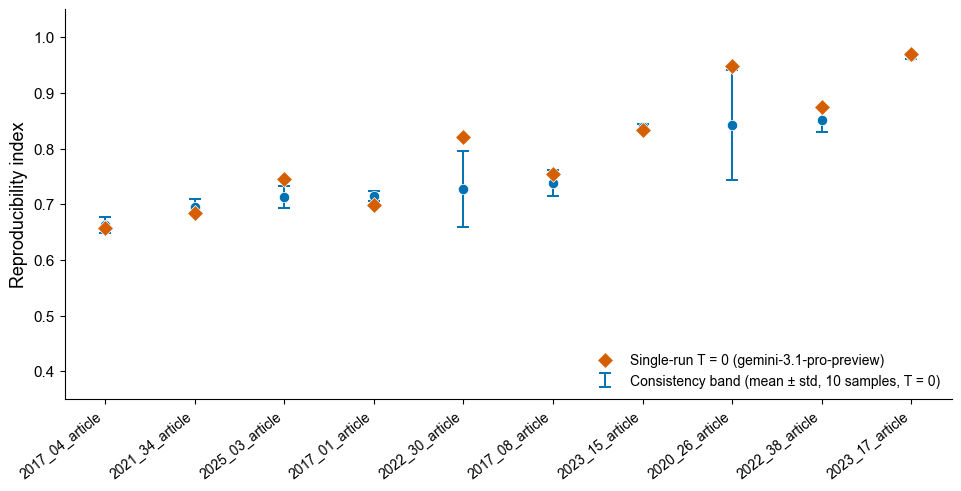

5/10 single-run scores fall within ±1 std of the consistency mean
              paper  mean   std  n  t0_single
2017_04_article.pdf 0.663 0.014  9      0.658
2021_34_article.pdf 0.696 0.013 10      0.683
2025_03_article.pdf 0.713 0.019  9      0.745
2017_01_article.pdf 0.715 0.008 10      0.699
2022_30_article.pdf 0.728 0.068 10      0.822
2017_08_article.pdf 0.738 0.023  9      0.755
2023_15_article.pdf 0.838 0.006 10      0.833
2020_26_article.pdf 0.842 0.099  9      0.948
2022_38_article.pdf 0.851 0.021 10      0.875
2023_17_article.pdf 0.966 0.006 10      0.971


In [12]:
import json
import re as _re
from repro_scoring import score_profile as _score_profile

_T0_DIR  = Path("data/experiments/rescience_c_gemini3_1_pro_T0")
_STEM_T0 = _re.compile(r"^(?P<year>\d{4})_(?P<num>\d+)_article_T0_(?P<model>.+)$")

consistency_papers = set(long["paper"].unique())

# Load single-run T=0 scores from the full-corpus dataset for the 10 shared papers
t0_scores: dict = {}
for _path in sorted(_T0_DIR.glob("*.profile.json")):
    _stem = _path.stem.removesuffix(".profile")
    _m    = _STEM_T0.match(_stem)
    if _m is None:
        continue
    _paper = f"{_m['year']}_{_m['num']}_article.pdf"
    if _paper not in consistency_papers:
        continue
    try:
        _profile = json.loads(_path.read_text(encoding="utf-8"))
    except (json.JSONDecodeError, UnicodeDecodeError):
        continue
    t0_scores[_paper] = _score_profile(_profile)["repro_index"]

# 10-sample consistency band at T=0 for gemini-3.1-pro-preview
cons_t0 = (
    long[(long["model"] == "gemini-3.1-pro-preview") & (long["temperature"] == 0.0)]
    .groupby("paper")["repro_index"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
    .assign(std=lambda d: d["std"].fillna(0.0))
)
cons_t0["t0_single"] = cons_t0["paper"].map(t0_scores)
cons_t0 = cons_t0.dropna(subset=["t0_single"]).sort_values("mean").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.5, 4.8), constrained_layout=True)
x = range(len(cons_t0))

ax.errorbar(
    x, cons_t0["mean"], yerr=cons_t0["std"],
    fmt="none", color="#0072B2", capsize=4, linewidth=1.4, capthick=1.4,
    label="Consistency band (mean \u00b1 std, 10 samples, T = 0)",
)
ax.scatter(x, cons_t0["mean"], color="#0072B2", s=55, zorder=4,
           edgecolors="white", linewidths=0.5)
ax.scatter(
    x, cons_t0["t0_single"],
    color="#D55E00", marker="D", s=65, zorder=5,
    edgecolors="white", linewidths=0.5,
    label="Single-run T = 0 (gemini-3.1-pro-preview)",
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [p.removesuffix(".pdf") for p in cons_t0["paper"]],
    rotation=38, ha="right", fontsize=10,
)
ax.set_ylabel("Reproducibility index")
ax.set_ylim(0.35, 1.05)
ax.legend(loc="lower right", fontsize=10, borderaxespad=0.4)

fig.savefig(FIGURE_DIR / "fig8_cross_validation.pdf")
fig.savefig(FIGURE_DIR / "fig8_cross_validation.png")
plt.show()

within = (
    (cons_t0["t0_single"] >= cons_t0["mean"] - cons_t0["std"]) &
    (cons_t0["t0_single"] <= cons_t0["mean"] + cons_t0["std"])
).sum()
print(f"{within}/{len(cons_t0)} single-run scores fall within \u00b11 std of the consistency mean")
print(cons_t0[["paper", "mean", "std", "n", "t0_single"]].round(3).to_string(index=False))

: 

: 